# Build Dictionary
Maps clustered sound units to English words and decodes Rocky's sentences.
See `docs/build_dictionary.md` for theory.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
from collections import Counter

print('ready')

ready


## Load

In [2]:
labels      = np.load('../data/cluster_labels.npy')
onset_times = np.load('../data/onset_times.npy')

with open('../data/dictionary.json', 'r') as f:
    dictionary = json.load(f)

cluster_map    = dictionary['cluster_map']       # cluster id → sound name
sentences      = dictionary['sentences']          # sentence name → sound list
english_meaning = dictionary['english_meaning']  # sentence name → english

print(f'units detected  : {len(labels)}')
print(f'cluster map     : {len(cluster_map)} clusters')
print(f'known sentences : {len(sentences)}')
print()
print('cluster map loaded:')
for k, sound in cluster_map.items():
    print(f'  cluster {k:>2} → {sound}')

units detected  : 28
cluster map     : 10 clusters
known sentences : 5

cluster map loaded:
  cluster  0 → hum_mid
  cluster  1 → click_high
  cluster  2 → chirp_up
  cluster  3 → hum_mid
  cluster  4 → click_high
  cluster  5 → hum_low
  cluster  7 → chirp_down
  cluster  8 → chirp_up
  cluster  9 → chord_simple
  cluster 10 → click_high


## Defining the sound to English word mapping

In [3]:
# sound name → English word
# designed so sequences of these words form readable sentences
SOUND_TO_WORD = {
    'click_low'    : 'I',
    'click_mid'    : 'here',
    'click_high'   : 'warning',
    'hum_low'      : 'what',
    'hum_mid'      : 'am',
    'hum_high'     : 'safe',
    'chirp_up'     : 'question',
    'chirp_down'   : 'danger',
    'chord_simple' : 'understand',
    'chord_rich'   : 'need',
    'chord_alien'  : 'critical',
}

print('sound → word mapping:')
for sound, word in SOUND_TO_WORD.items():
    print(f'  {sound:20} → {word}')

sound → word mapping:
  click_low            → I
  click_mid            → here
  click_high           → warning
  hum_low              → what
  hum_mid              → am
  hum_high             → safe
  chirp_up             → question
  chirp_down           → danger
  chord_simple         → understand
  chord_rich           → need
  chord_alien          → critical


## Verifying by decoding known sentences using the mapping

In [4]:
print('decoding known sentences:\n')
for sentence_name, sound_list in sentences.items():
    words    = [SOUND_TO_WORD.get(s, '?') for s in sound_list]
    meaning  = english_meaning[sentence_name]
    print(f'  sentence      : {sentence_name}')
    print(f'  sounds        : {" → ".join(sound_list)}')
    print(f'  words         : {" → ".join(words)}')
    print(f'  known meaning : {meaning}')
    print()

decoding known sentences:

  sentence      : greeting
  sounds        : click_high → click_high → hum_mid → chirp_up → click_mid
  words         : warning → warning → am → question → here
  known meaning : Hello / I am here

  sentence      : question
  sounds        : hum_low → click_mid → click_low → chirp_up → chirp_up
  words         : what → here → I → question → question
  known meaning : What is this?

  sentence      : danger
  sounds        : chirp_down → chirp_down → chord_alien → click_high → click_high → click_high
  words         : danger → danger → critical → warning → warning → warning
  known meaning : Warning! Danger!

  sentence      : i_understand
  sounds        : chord_simple → hum_mid → click_low → hum_high → chord_rich
  words         : understand → am → I → safe → need
  known meaning : I understand

  sentence      : help_needed
  sounds        : chirp_up → chord_alien → hum_low → chirp_down → click_high → chord_rich
  words         : question → critical → what

## Decoding the detected audio using cluster labels

This is the real test : take the cluster sequence the detector found and convert it to words.

In [5]:
def decode_sequence(cluster_labels, cluster_map, sound_to_word):
    """
    cluster ID → sound name → english word
    returns list of (cluster_id, sound_name, word, onset_time)
    """
    results = []
    for i, label in enumerate(cluster_labels):
        sound_name = cluster_map.get(str(label), 'unknown')
        word       = sound_to_word.get(sound_name, '?')
        onset_t    = onset_times[i] if i < len(onset_times) else 0
        results.append((int(label), sound_name, word, round(float(onset_t), 3)))
    return results

decoded = decode_sequence(labels, cluster_map, SOUND_TO_WORD)

print(f'full decoded sequence ({len(decoded)} units):\n')
print(f'{"#":4} {"time":8} {"cluster":8} {"sound":20} {"word"}')
print('-' * 55)
for i, (cluster, sound, word, t) in enumerate(decoded):
    print(f'{i:4} {t:8.3f} {cluster:8} {sound:20} {word}')

full decoded sequence (28 units):

#    time     cluster  sound                word
-------------------------------------------------------
   0    0.102        1 click_high           warning
   1    0.223        4 click_high           warning
   2    0.551        0 hum_mid              am
   3    0.772        2 chirp_up             question
   4    1.309        4 click_high           warning
   5    1.672        5 hum_low              what
   6    1.791        5 hum_low              what
   7    1.913        0 hum_mid              am
   8    2.148        8 chirp_up             question
   9    2.781        0 hum_mid              am
  10    3.007        0 hum_mid              am
  11    3.242        7 chirp_down           danger
  12    3.556        1 click_high           warning
  13    3.666        1 click_high           warning
  14    3.776       10 click_high           warning
  15    4.304        5 hum_low              what
  16    4.365        9 chord_simple         understand
 

## Detect sentence boundaries
Group units into sentences using time gaps — a long gap between units = new sentence.

In [10]:
SENTENCE_GAP = 0.5   # seconds — gap larger than this = new sentence

sentences_detected = []
current_sentence   = [decoded[0]]

for i in range(1, len(decoded)):
    gap = decoded[i][3] - decoded[i-1][3]
    if gap > SENTENCE_GAP:
        sentences_detected.append(current_sentence)
        current_sentence = []
    current_sentence.append(decoded[i])

if current_sentence:
    sentences_detected.append(current_sentence)

print(f'sentences detected: {len(sentences_detected)}\n')
for i, sentence in enumerate(sentences_detected):
    words = [unit[2] for unit in sentence]
    t_start = sentence[0][3]
    print(f'  sentence {i+1} (t={t_start:.2f}s): {" ".join(words)}')

sentences detected: 5

  sentence 1 (t=0.10s): warning warning am question
  sentence 2 (t=1.31s): warning what what am question
  sentence 3 (t=2.78s): am am danger warning warning warning
  sentence 4 (t=4.30s): what understand am warning what am question
  sentence 5 (t=6.08s): am danger warning am warning ?


## Visualize the decoded sequence

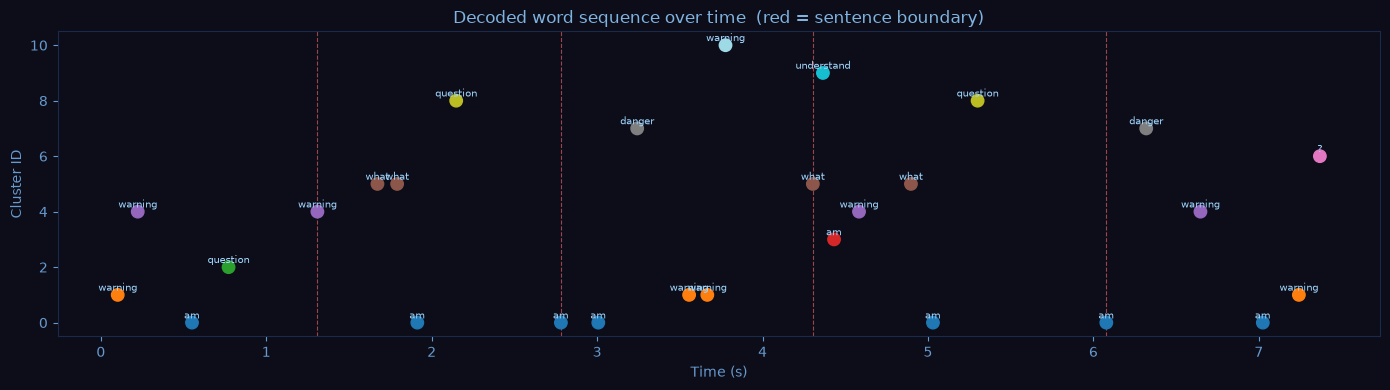

In [11]:
fig, ax = plt.subplots(figsize=(14, 4), facecolor='#0d0d1a')
ax.set_facecolor('#0d0d1a')
ax.tick_params(colors='#6699cc')
ax.xaxis.label.set_color('#6699cc')
ax.yaxis.label.set_color('#6699cc')
for s in ax.spines.values(): s.set_edgecolor('#1a2a4a')

times = [d[3] for d in decoded]
words = [d[2] for d in decoded]
clusters = [d[0] for d in decoded]

ax.scatter(times, clusters, c=clusters, cmap='tab20', s=80, zorder=3)
for t, w, c in zip(times, words, clusters):
    ax.text(t, c + 0.15, w, color='#a0d8ff', fontsize=7, ha='center')

# mark sentence boundaries
for sentence in sentences_detected[1:]:
    ax.axvline(x=sentence[0][3], color='#ff6b6b', linewidth=0.8,
               linestyle='--', alpha=0.6)

ax.set(title='Decoded word sequence over time  (red = sentence boundary)',
       xlabel='Time (s)', ylabel='Cluster ID')
ax.title.set_color('#80b4e0')
plt.tight_layout()
plt.savefig('../audio/decoded_sequence.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

## Save the completed dictionary

In [12]:
dictionary['sound_to_word']       = SOUND_TO_WORD
dictionary['decoded_sequence']    = [(c, s, w, t) for c, s, w, t in decoded]
dictionary['sentences_detected']  = [
    {
        'start_time' : s[0][3],
        'words'      : [u[2] for u in s],
        'sounds'     : [u[1] for u in s],
    }
    for s in sentences_detected
]

with open('../data/dictionary.json', 'w') as f:
    json.dump(dictionary, f, indent=2)

print('saved  data/dictionary.json  updated')
print()
print('sentences saved to dictionary:')
for i, s in enumerate(dictionary['sentences_detected']):
    print(f'  {i+1}. {" ".join(s["words"])}')


saved  data/dictionary.json  updated

sentences saved to dictionary:
  1. warning warning am question
  2. warning what what am question
  3. am am danger warning warning warning
  4. what understand am warning what am question
  5. am danger warning am warning ?
